# Lab 2: Data Analysis with Pandas and Sensor Data

## Setup

Let's start by importing necessary libraries:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import glob
import seaborn as sns

Next, we define an array of objects to easily access our data paths:

In [2]:
classes = ['jumping', 'walking', 'running', 'stairs']
categories = ["train", "valid", "test"]

## Handling the data

### Convert recordings into pickle files

This function reads accelerometer and gyroscope data from CSV files, plots them, merges them into a single DataFrame, and returns the merged DataFrame.

In [3]:
def merge_recordings(path_acc, path_gyro):
    dataset_acc = (
        pd.read_csv(path_acc,
                    usecols=[1,2,3],
                    names=['ax', 'ay', 'az'],
                    skiprows=[0],
                    dtype=str
                   )
        .replace({r"×10\^": "e"}, regex=True)
        .apply(pd.to_numeric)
    )
    
    dataset_gyro = (
        pd.read_csv(path_gyro,
                    usecols=[1,2,3],
                    names=['gx', 'gy', 'gz'],
                    skiprows=[0],
                    dtype=str
                   )
        .replace({r"×10\^": "e"}, regex=True)
        .apply(pd.to_numeric)
    )

    # dataset_acc.plot(title=f"Accelerometer (raw)", figsize=(20, 6))
    # plt.show()
    # dataset_gyro.plot(title=f"Gyroscope (raw)", figsize=(20, 6))
    # plt.show()

    return pd.concat([dataset_acc, dataset_gyro], axis=1)

This code iterates over all classes and recordings in your dataset, merges the corresponding accelerometer and gyroscope CSV files, and saves the merged data as pickled DataFrames in separate folders for training, validation, and testing.

In [4]:
for classname in classes:
    for i in range(1, 9):
        recording = f'{classname}_{i}'
        acc_path = os.path.join('../data', recording, "Accelerometer.csv")
        gyro_path = os.path.join('../data', recording, "Gyroscope.csv")

        if 1 <= i <= 5:
            pickle_path = os.path.join('../pickles/original', 'train', classname, f'{recording}.pkl')
        elif 6 <= i <= 7:
            pickle_path = os.path.join('../pickles/original', 'valid', classname, f'{recording}.pkl')
        else:
            pickle_path = os.path.join('../pickles/original', 'test', classname, f'{recording}.pkl')

        df = merge_recordings(acc_path, gyro_path)
        df.to_pickle(pickle_path)
        print(f"Saved {pickle_path}")
        print(df.head())

Saved ../pickles/original/train/jumping/jumping_1.pkl
         ax        ay        az        gx        gy        gz
0 -0.467029  5.075795  8.625813  0.052829 -0.106194  0.036081
1 -0.320933  5.026547  8.536149  0.031697 -0.112803  0.023143
2 -0.164658  4.940925  8.451874  0.009204 -0.105260  0.007855
3 -0.076790  4.872667  8.385263 -0.006973 -0.090072 -0.007174
4 -0.043410  4.823569  8.435558 -0.003647 -0.083001 -0.017000
Saved ../pickles/original/train/jumping/jumping_2.pkl
         ax        ay        az        gx        gy        gz
0 -1.563050  1.457519  9.476194  0.030738 -0.056625  0.021494
1 -1.404380  1.484014  9.500593 -0.015226 -0.031653  0.010648
2 -1.320105  1.449586  9.523346 -0.046974 -0.023298 -0.018883
3 -1.290616  1.449586  9.548344 -0.064505 -0.025163 -0.046851
4 -1.320255  1.490600  9.591604 -0.068160 -0.023444 -0.067647
Saved ../pickles/original/train/jumping/jumping_3.pkl
         ax        ay         az        gx        gy        gz
0  0.555195 -0.115859   9.14104

In [5]:
def combine_pickles_of_class(path):
    """
    Combines multiple pickle files from one class into a single dataframe with a 'class' column.
    """
    dfs = []
    classname = os.path.basename(path)
    for file in os.listdir(path):
        if file.endswith(".pkl") and classname in file:
            df = pd.read_pickle(os.path.join(path, file))
            df["class"] = classname
            dfs.append(df)
    return (pd.concat(dfs, ignore_index=True))

In [6]:
for classname in classes:
    for category in categories:
        base_path = os.path.join("../pickles/original", category)
        class_path = os.path.join(base_path, classname)
        pickle_path = os.path.join(base_path, f'{classname}_combined.pkl')
        df = combine_pickles_of_class(class_path)
        print(f"Saved {pickle_path}")
        print(df.head())
        df.to_pickle(pickle_path)

Saved ../pickles/original/train/jumping_combined.pkl
         ax        ay         az        gx        gy        gz    class
0  0.326321 -0.026046   8.939560 -0.029586 -0.042328 -0.006043  jumping
1  0.365839 -0.231568   9.616752 -0.009844 -0.017801 -0.006260  jumping
2  0.266147 -0.280367  10.299183  0.038480 -0.009049 -0.001547  jumping
3  0.211660 -0.176782  10.291698  0.039289 -0.036200 -0.001120  jumping
4  0.190254 -0.184866   9.820778  0.012137 -0.057905 -0.003597  jumping
Saved ../pickles/original/valid/jumping_combined.pkl
         ax        ay        az        gx        gy        gz    class
0 -3.098257  1.936074  8.773106 -0.060890 -0.181097  0.058706  jumping
1 -3.191214  1.899849  8.904982 -0.104530 -0.216885  0.059278  jumping
2 -3.153642  1.883683  9.198821 -0.125164 -0.242111  0.050866  jumping
3 -3.015928  1.892964  9.374106 -0.133920 -0.259998  0.050168  jumping
4 -2.999912  1.883683  9.370664 -0.137685 -0.286546  0.065080  jumping
Saved ../pickles/original/test/jumpi

## Statistics

In this section we explore the statistical properties of the recorded movement data.

### Use the describe method for all four classes.

First, we use the `.describe()` method on each class separately (walking, running, jumping, and the additional movement). This provides measures such as mean, standard deviation, minimum, and quartiles.

In [7]:
original_train_dfs = []
for classname in classes:
    df = pd.read_pickle(f"../pickles/original/train/{classname}_combined.pkl")
    original_train_dfs.append(df)
    print(f"\nStatistics for {classname}:")
    display(df.describe())


Statistics for jumping:


,ax,ay,az,gx,gy,gz
count,14259.000000,14259.000000,14259.000000,14257.000000,14257.000000,14257.000000
mean,0.571966,8.623553,-0.134490,0.017337,0.061695,0.024317
std,4.200339,14.096149,5.054513,0.903959,1.137570,0.816497
min,-26.363477,-8.546777,-42.859324,-5.988524,-5.509972,-3.126703
25%,-0.637898,-0.834964,-1.637370,-0.455282,-0.621374,-0.451601
50%,0.335003,4.800368,-0.044008,0.090695,0.027088,0.072516
75%,1.657428,11.427312,1.534908,0.471937,0.695773,0.452611
max,61.519819,93.202634,17.204323,4.847057,6.250481,6.488885



Statistics for walking:


,ax,ay,az,gx,gy,gz
count,13311.000000,13311.000000,13311.000000,13309.000000,13309.000000,13309.000000
mean,0.298540,9.055466,-0.372309,-0.017867,0.035571,-0.057944
std,2.815544,3.544819,3.931646,1.189128,0.959130,0.687935
min,-24.565416,-10.628648,-18.163379,-5.276205,-5.494538,-3.499262
25%,-0.718730,6.560632,-2.426005,-0.876942,-0.525671,-0.476358
50%,0.461939,8.741821,-0.354313,-0.163737,-0.036760,-0.092825
75%,1.527948,11.314222,1.296978,0.832253,0.628317,0.341207
max,38.894219,54.154984,16.092885,4.765286,6.825296,7.733553



Statistics for running:


,ax,ay,az,gx,gy,gz
count,12975.000000,12975.000000,12975.000000,12974.000000,12974.000000,12974.000000
mean,-3.283230,8.418698,-0.065664,-0.020620,0.255480,-0.051750
std,6.587545,10.900170,4.648138,1.797408,2.124165,1.973247
min,-48.614406,-8.430918,-34.982703,-7.857191,-11.824735,-9.707191
25%,-6.938297,0.916619,-2.368824,-0.808910,-0.920661,-0.829621
50%,-1.523981,6.643784,0.299377,0.052186,0.264453,0.334008
75%,1.084719,11.534713,2.420392,0.881598,1.471289,1.177950
max,16.638500,72.387519,26.319019,6.778691,9.760624,7.550404



Statistics for stairs:


,ax,ay,az,gx,gy,gz
count,13027.000000,13027.000000,13027.000000,13026.000000,13026.000000,13026.000000
mean,-2.990099,8.386956,-1.312003,0.094125,-0.328527,0.050075
std,2.579494,2.903074,3.256965,1.006486,1.167538,0.607929
min,-14.091996,-2.601440,-18.108144,-4.709187,-7.898367,-3.166898
25%,-4.595144,6.930363,-3.060161,-0.557099,-0.888403,-0.237933
50%,-3.031047,8.408165,-1.484762,0.010030,-0.202115,0.017856
75%,-1.267938,9.682989,-0.509091,0.713688,0.382395,0.295583
max,7.341034,45.283682,15.176341,4.322839,8.142892,5.966421


**Observations from Descriptive Statistics**

- **Jumping**
  - Very high variability in accelerometer `ay` (std ≈ 14.1) compared to other classes, with a maximum close to 93, reflecting strong vertical acceleration during jumps.  
  - Accelerometer `ax` and `az` also span wide ranges, with extreme outliers (e.g., `ax` min ≈ –26, max ≈ 61).  
  - Gyroscope values small and centered around zero, indicating limited rotation.  

- **Walking**
  - Accelerometer values are more stable, with lower standard deviations (`ay` std ≈ 3.5).  
  - Means are near zero for `ax` and `az`, while `ay` centers around ~9, consistent with steady vertical support against gravity.  
  - Gyroscope values are small and centered around zero, indicating limited rotation.  

- **Running**
  - Strong variability across accelerometer axes (`ax` std ≈ 6.6, `ay` std ≈ 10.9).  
  - The mean of `ax` is negative (≈ –3.28).
  - Gyroscope values show the largest spread among classes.  

- **Stairs**
  - Negative means in `ax` and `az` (≈ –2.99 and –1.31).  
  - Lower variability than running and jumping, suggesting more controlled motion.  
  - Gyroscope values show greater variation than walking, but less than running.  

### Make boxplots of each class for all features.

Next, we create boxplots for each feature grouped by class. Boxplots allow us to visually compare the distribution of sensor values across classes. They highlight differences in spread, median values, and the presence of outliers.

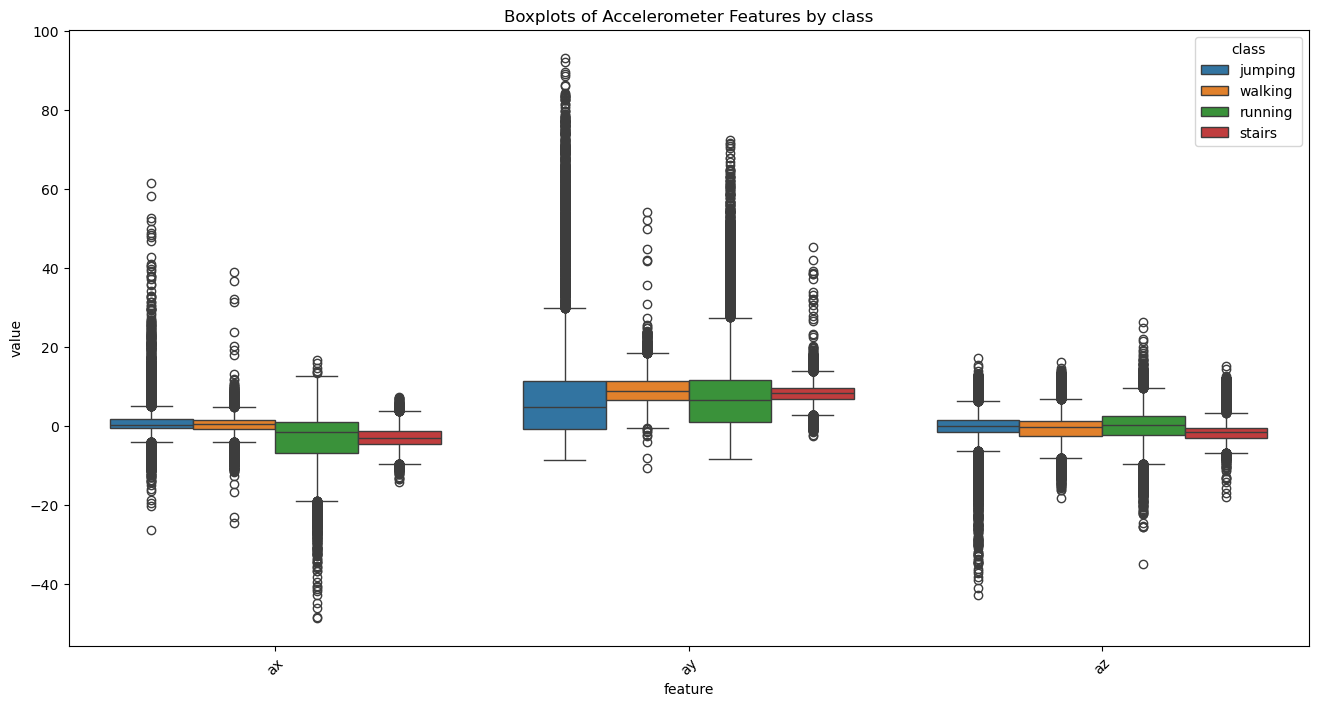

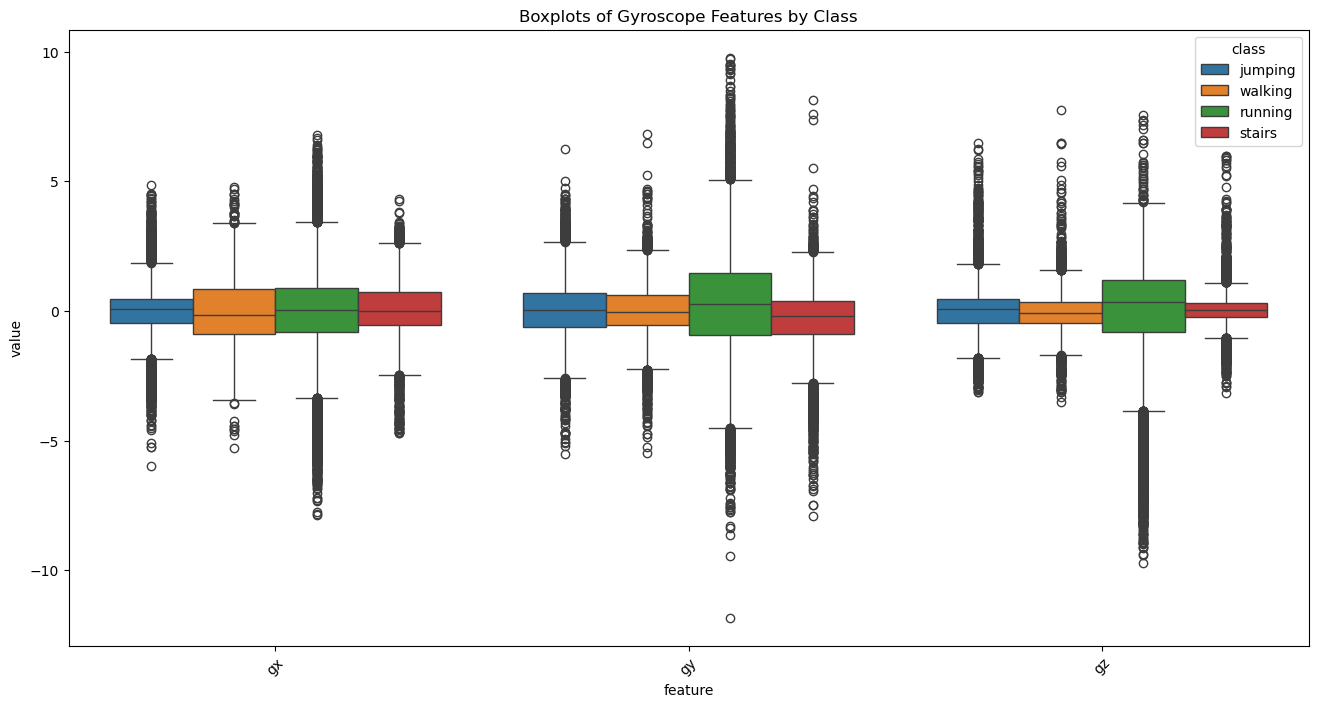

In [8]:
all_data = pd.concat(original_train_dfs, ignore_index=True)

melted = all_data.melt(id_vars="class", var_name="feature", value_name="value")
acc_features = melted[melted["feature"].str.startswith("a")]
gyro_features = melted[melted["feature"].str.startswith("g")]

# Plot accelerometer features
plt.figure(figsize=(16, 8))
sns.boxplot(data=acc_features, x="feature", y="value", hue="class")
plt.title("Boxplots of Accelerometer Features by class")
plt.xticks(rotation=45)
plt.show()

# Plot gyroscope features
plt.figure(figsize=(16, 8))
sns.boxplot(data=gyro_features, x="feature", y="value", hue="class")
plt.title("Boxplots of Gyroscope Features by Class")
plt.xticks(rotation=45)
plt.show()

The boxplots reveal clear differences between the four movement classes (jumping, walking, running, stairs) for both accelerometer and gyroscope features.

**Accelerometer:**
- The `ay` axis shows the largest variation across classes. Running and jumping have a wider spread compared to walking and stairs, which indicates more vertical acceleration in these activities.
- The `ax` and `az` axes also differ, but less consistently. Running tends to show more spread, while walking and stairs have tighter distributions centered near zero.
- Jumping shows strong outliers, especially in `ay` and `az`, which reflects the impulsive nature of the movement.

**Gyroscope:**
- Running exhibits the largest variance in all gyroscope axes, with clear separation from the other classes. This suggests more frequent and intense rotational movements when running, which makes sense since the chosen area to take the measurements was circular.
- Walking and stairs look similar in the gyroscope domain, with smaller spreads and medians close to zero, but stairs occasionally show higher values in `gy`, which could reflect balance adjustments when climbing.
- Jumping has relatively narrow gyroscope distributions, since the movement is primarily vertical with less rotation compared to running or stair climbing.

## Clean the Data

When plotting the raw sensor data, some irregularities appear at the beginning and the end of the recordings.  
These irregularities are caused by the moments when the recording was started and the phone was being placed in the pocket, and again when the phone was removed at the end to stop the recording. During these transitions, the movements do not represent the intended activity and therefore introduce noise into the dataset.

The following function reads accelerometer and gyroscope data from CSV files, drop first 500 and last 1000 rows, plots them, merges them into a single DataFrame, and returns the merged DataFrame.

In [9]:
def clean_and_merge_recordings(path_acc, path_gyro):
    dataset_acc = (
        pd.read_csv(path_acc,
                    usecols=[1,2,3],
                    names=['ax', 'ay', 'az'],
                    skiprows=[0],
                    dtype=str
                   )
        .replace({r"×10\^": "e"}, regex=True)
        .apply(pd.to_numeric)
    ).iloc[500:-1000]
    
    dataset_gyro = (
        pd.read_csv(path_gyro,
                    usecols=[1,2,3],
                    names=['gx', 'gy', 'gz'],
                    skiprows=[0],
                    dtype=str
                   )
        .replace({r"×10\^": "e"}, regex=True)
        .apply(pd.to_numeric)
    ).iloc[500:-1000]

    # dataset_acc.plot(title=f"Accelerometer (raw)", figsize=(20, 6))
    # plt.show()
    # dataset_gyro.plot(title=f"Gyroscope (raw)", figsize=(20, 6))
    # plt.show()
    
    return pd.concat([dataset_acc, dataset_gyro], axis=1)

The following block of code iterates over all classes and recordings in our dataset, merges the corresponding accelerometer and gyroscope CSV files, and saves the merged data as pickled DataFrames in separate folders for training, validation, and testing, inside the pickles/cleaned dir.

In [10]:
for classname in classes:
    for i in range(1, 9):
        recording = f'{classname}_{i}'
        acc_path = os.path.join('../data', recording, "Accelerometer.csv")
        gyro_path = os.path.join('../data', recording, "Gyroscope.csv")
        
        pickle_path = '../pickles/cleaned'
        if 1 <= i <= 5:
            pickle_path = os.path.join(pickle_path, 'train', classname, f'{recording}_clean.pkl')
        elif 6 <= i <= 7:
            pickle_path = os.path.join(pickle_path, 'valid', classname, f'{recording}_clean.pkl')
        else:
            pickle_path = os.path.join(pickle_path, 'test', classname, f'{recording}_clean.pkl')

        df = clean_and_merge_recordings(acc_path, gyro_path)
        df.to_pickle(pickle_path)
        print(f"Saved {pickle_path}")
        print(df.head())

Saved ../pickles/cleaned/train/jumping/jumping_1_clean.pkl
           ax        ay        az        gx        gy        gz
500  0.125739 -1.532214  1.808240  0.266598 -0.432266 -0.355869
501  0.064666 -1.359772  1.715133  0.297908 -0.138412 -0.418102
502 -0.011526 -1.442401  1.639990  0.347524  0.133105 -0.464512
503 -0.138312 -1.569636  1.606310  0.412923  0.353208 -0.496677
504 -0.286953 -1.736838  1.581312  0.537493  0.372099 -0.530052
Saved ../pickles/cleaned/train/jumping/jumping_2_clean.pkl
           ax         ay        az        gx        gy        gz
500  0.526605   3.571573 -1.179098  0.103017  2.195909 -1.289934
501  0.555495   4.222270 -2.500550 -0.191600  1.673514 -1.473169
502  0.684976   4.326902 -1.126258 -0.366087  1.111051 -1.684981
503 -0.858315   8.792117 -0.964893 -0.555641  0.711940 -1.661083
504 -5.525759  22.132974 -2.873125 -0.768300  0.074259 -0.871419
Saved ../pickles/cleaned/train/jumping/jumping_3_clean.pkl
           ax        ay        az        gx      

To simplify, let's combine all data from the same class into one combined file:

In [11]:
for classname in classes:
    for category in categories:
        base_path = os.path.join("../pickles/cleaned", category)
        class_path = os.path.join(base_path, classname)
        pickle_path = os.path.join(base_path, f'{classname}_combined.pkl')
        df = combine_pickles_of_class(class_path)
        print(f"Saved {pickle_path}")
        print(df.head())
        df.to_pickle(pickle_path)

Saved ../pickles/cleaned/train/jumping_combined.pkl
         ax        ay        az        gx        gy        gz    class
0  0.383652 -1.372795  1.474733  0.078162  0.284137  0.534385  jumping
1  0.310754 -2.051334  1.819616  0.179830  0.758931  0.523735  jumping
2  0.334405 -2.462230  1.866169  0.325957  1.053100  0.540324  jumping
3  0.300126 -2.684518  1.656306  0.490372  1.160967  0.570663  jumping
4  0.199984 -2.669848  1.493893  0.656023  1.075032  0.599874  jumping
Saved ../pickles/cleaned/valid/jumping_combined.pkl
         ax        ay        az        gx        gy        gz    class
0  0.504900 -2.088906  0.386197  0.521802  0.513097  0.737274  jumping
1  0.315544 -1.968856  0.195044  0.457572  0.973838  0.882794  jumping
2  0.214953 -1.865421 -0.107027  0.413849  1.271351  1.000455  jumping
3  0.216300 -1.861679 -0.405207  0.452946  1.383463  1.073848  jumping
4  0.219444 -1.972299 -0.434696  0.550555  1.375371  1.096808  jumping
Saved ../pickles/cleaned/test/jumping_combin

### Using the describe method for all four classes.

After cleaning our data, we use the `.describe()` method on each class separately (walking, running, jumping, and the additional movement). This provides measures such as mean, standard deviation, minimum, and quartiles.

In [12]:
cleaned_train_dfs = []
for classname in classes:
    df = pd.read_pickle(f"../pickles/cleaned/train/{classname}_combined.pkl")
    original_train_dfs.append(df)
    print(f"\nStatistics for {classname}:")
    display(df.describe())


Statistics for jumping:


,ax,ay,az,gx,gy,gz
count,6759.000000,6759.000000,6759.000000,6757.000000,6757.000000,6757.000000
mean,1.412725,9.525563,-1.315624,-0.007647,-0.007080,-0.003211
std,4.439052,16.727419,4.792114,0.884850,1.226627,0.836676
min,-13.606555,-8.546777,-42.859324,-5.097980,-5.205410,-2.551694
25%,-0.326247,-1.328637,-1.794094,-0.511270,-0.815633,-0.565549
50%,0.517175,2.273173,-0.227227,0.119280,-0.082836,0.096851
75%,2.028357,15.306495,1.080827,0.495909,0.752514,0.459991
max,61.519819,93.202634,13.827645,4.847057,4.466988,6.488885



Statistics for walking:


,ax,ay,az,gx,gy,gz
count,5811.000000,5811.000000,5811.000000,5809.000000,5809.000000,5809.000000
mean,0.893860,9.554760,-1.362622,-0.018317,0.008177,-0.069611
std,2.031039,3.440670,3.083513,1.216798,0.899490,0.613511
min,-5.606292,1.273851,-16.344362,-2.738929,-4.077773,-1.806598
25%,-0.292567,7.195761,-2.904111,-0.938059,-0.523430,-0.495899
50%,0.679138,9.376801,-0.790506,-0.262221,-0.087741,-0.132265
75%,1.636023,11.939996,0.667387,0.967228,0.610383,0.356986
max,10.867251,25.648564,9.500893,2.895721,2.583328,2.680722



Statistics for running:


,ax,ay,az,gx,gy,gz
count,5475.000000,5475.000000,5475.000000,5474.000000,5474.000000,5474.000000
mean,-2.993575,8.949398,-0.958271,-0.017753,0.265025,-0.051518
std,7.373379,12.737753,4.573516,1.931025,2.351065,2.182146
min,-48.614406,-7.921527,-25.651857,-7.857191,-8.643796,-9.707191
25%,-6.577996,-0.646356,-3.161650,-0.846561,-1.101222,-0.855845
50%,-0.866847,6.512058,0.024399,0.069657,0.293356,0.543617
75%,1.591341,12.807741,1.933529,0.935108,1.676980,1.296802
max,16.638500,72.387519,26.319019,6.667998,9.499514,4.709185



Statistics for stairs:


,ax,ay,az,gx,gy,gz
count,5527.000000,5527.000000,5527.000000,5526.000000,5526.000000,5526.000000
mean,-2.860437,8.755734,-2.137981,0.157369,-0.454718,0.088984
std,2.548192,2.323746,1.992003,1.003029,1.196813,0.467264
min,-14.091996,1.310525,-13.550721,-2.443349,-7.898367,-1.629766
25%,-4.441414,7.336544,-3.411181,-0.597652,-1.001894,-0.188876
50%,-2.981201,8.585247,-1.698668,0.008726,-0.302353,0.047810
75%,-1.232537,9.800195,-0.762589,0.829675,0.301027,0.321646
max,6.684949,20.286115,6.009104,3.427236,2.661065,2.173433


After trimming idle segments, the statistics now reflect true movement:

- **Jumping**:
    - Very high accelerations (ax up to 61 m/s², ay up to 93 m/s²)
    - Strong variability across all axes.
    - The gyroscope stays near zero during most of the recording (75%)
    - Maximums/minimums: ±4–6 rad/s → occasional bursts of rotation.
- **Walking**:
    - Lowest variability and smooth periodic signals.
    - Accelerations and rotations stay within a small range, showing the steady rhythm of walking.
- **Running**:
    - Much larger dynamic range than walking
    - Extreme acceleration peaks (ax down to −48 m/s², ay up to 72 m/s²)
    - High angular velocities.
- **Stairs**:
    - Means show a downward tilt (ax −2.8, az −2.1), probably due to body angle when ascending/descending stairs.
    - Std is moderate (2.5, 2.3, 1.9), more intense than walking but less than running.
    - Mean rotation near zero except gy slightly negative.

### Make boxplots of each class for all features.

Next, we create boxplots for each feature grouped by class. Boxplots allow us to visually compare the distribution of sensor values across classes. They highlight differences in spread, median values, and the presence of outliers.

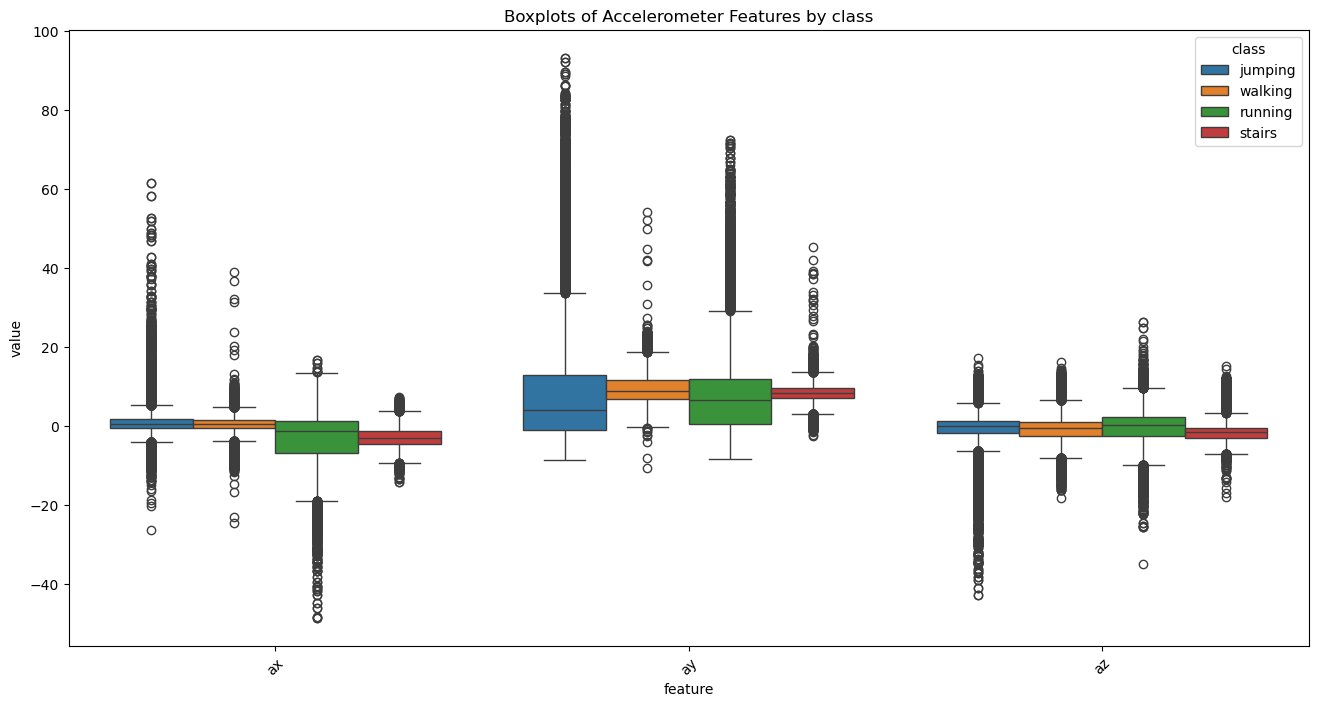

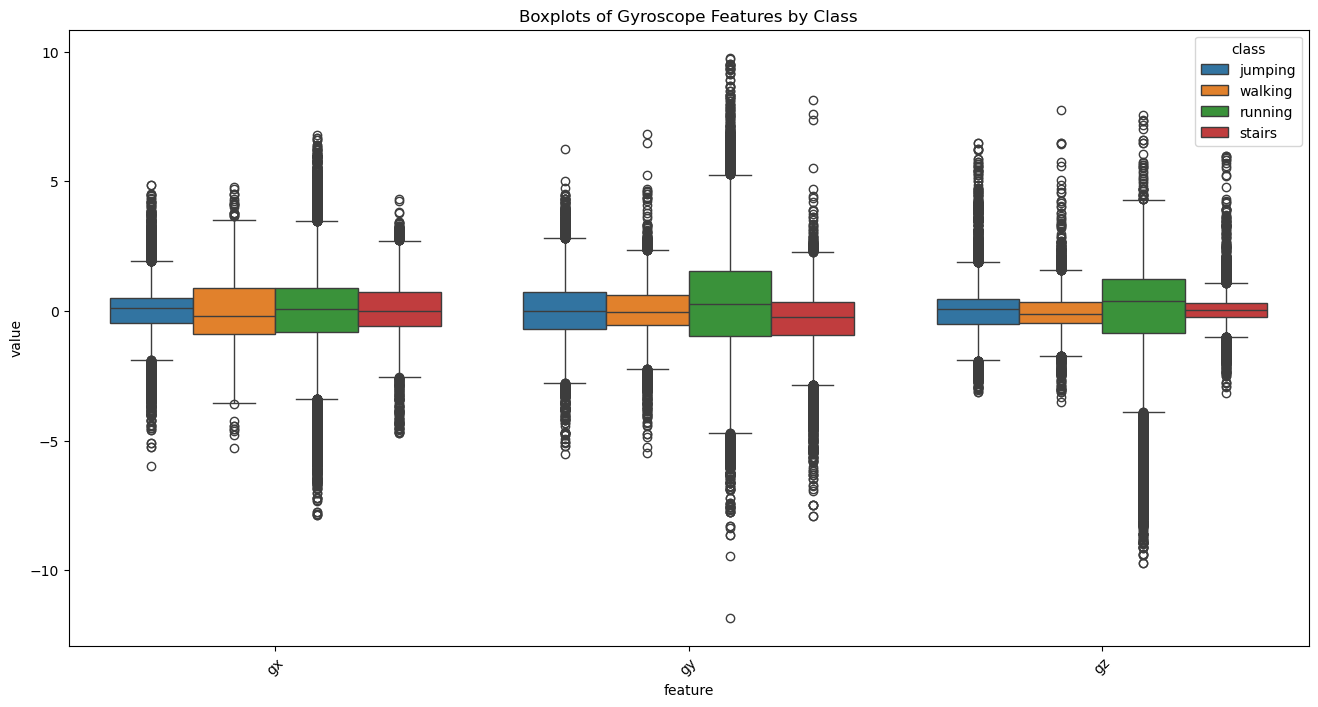

In [13]:
all_data = pd.concat(original_train_dfs, ignore_index=True)

melted = all_data.melt(id_vars="class", var_name="feature", value_name="value")
acc_features = melted[melted["feature"].str.startswith("a")]
gyro_features = melted[melted["feature"].str.startswith("g")]

# Plot accelerometer features
plt.figure(figsize=(16, 8))
sns.boxplot(data=acc_features, x="feature", y="value", hue="class")
plt.title("Boxplots of Accelerometer Features by class")
plt.xticks(rotation=45)
plt.show()

# Plot gyroscope features
plt.figure(figsize=(16, 8))
sns.boxplot(data=gyro_features, x="feature", y="value", hue="class")
plt.title("Boxplots of Gyroscope Features by Class")
plt.xticks(rotation=45)
plt.show()

Acceleration
- Jumping shows wide spread (especially for axis y) and many extreme outliers.
- Running shows the widest spread and many extreme outliers.
- Walking and stairs cluster tightly with small spreads and less extreme outliers.
- Medians across classes align with the expected orientation: ay around gravity (~9 m/s²), and the rest near zero.

## Combine data

The `combine_all_pickles` function organize and preprocess the data collected from different movement recordings. Each movement class (walking, running, jumping, stairs) has been recorded multiple times and stored together into one pickle files per class. To perform classification tasks later in the lab, these files need to be combined into a single, consistent dataset that also contains a label for the class each recording belongs to.

In [14]:
def combine_all_pickles(src_path, category):
    """
    Combine all pickle files from a given folder into one dataframe.
    
    Parameters
    ----------
    folder : str
        Name of the folder containing the pickles (e.g. 'training' or 'test').
    
    Returns
    -------
    pd.DataFrame
        Dataframe with all combined data and a 'class' column added.
    """
    dfs = []
    for classname in classes:
        class_path = os.path.join(src_path, category, f"{classname}_combined.pkl")
    
        if not class_path:
            raise FileNotFoundError(f"No pickle files found for class '{classname}' in folder '{category}'")
    
        df = pd.read_pickle(class_path)
        df['class'] = classname
        dfs.append(df)
    
    combined_df = pd.concat(dfs, axis=0, ignore_index=True).dropna()
    combined_path = os.path.join('../pickles/combined', f"{category}_df.pkl")
    combined_df.to_pickle(combined_path)
    print(f"Saved {combined_path}")
    print(combined_df.head())

    return combined_df

Once the function `combine_all_pickles` has been defined, we can use it to merge all recordings for each dataset category (train, valid, and test). The following loop iterates through every category folder defined in `categories`, which contains `["train", "valid", "test"]`:

In [15]:
for category in categories:
    combined_df = combine_all_pickles('../pickles/cleaned', category)

Saved ../pickles/combined/train_df.pkl
         ax        ay        az        gx        gy        gz    class
0  0.383652 -1.372795  1.474733  0.078162  0.284137  0.534385  jumping
1  0.310754 -2.051334  1.819616  0.179830  0.758931  0.523735  jumping
2  0.334405 -2.462230  1.866169  0.325957  1.053100  0.540324  jumping
3  0.300126 -2.684518  1.656306  0.490372  1.160967  0.570663  jumping
4  0.199984 -2.669848  1.493893  0.656023  1.075032  0.599874  jumping
Saved ../pickles/combined/valid_df.pkl
         ax        ay        az        gx        gy        gz    class
0  0.504900 -2.088906  0.386197  0.521802  0.513097  0.737274  jumping
1  0.315544 -1.968856  0.195044  0.457572  0.973838  0.882794  jumping
2  0.214953 -1.865421 -0.107027  0.413849  1.271351  1.000455  jumping
3  0.216300 -1.861679 -0.405207  0.452946  1.383463  1.073848  jumping
4  0.219444 -1.972299 -0.434696  0.550555  1.375371  1.096808  jumping
Saved ../pickles/combined/test_df.pkl
         ax        ay        az 

To visualize our data, let's plot the resulting daatframe on each category:

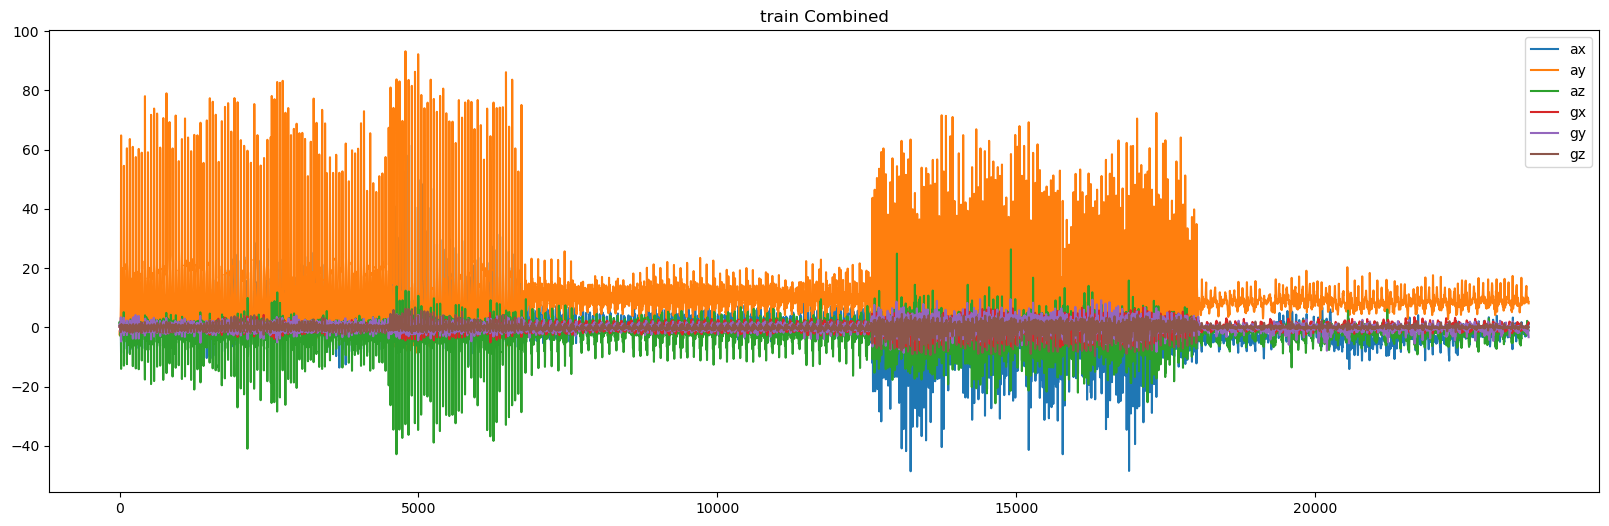

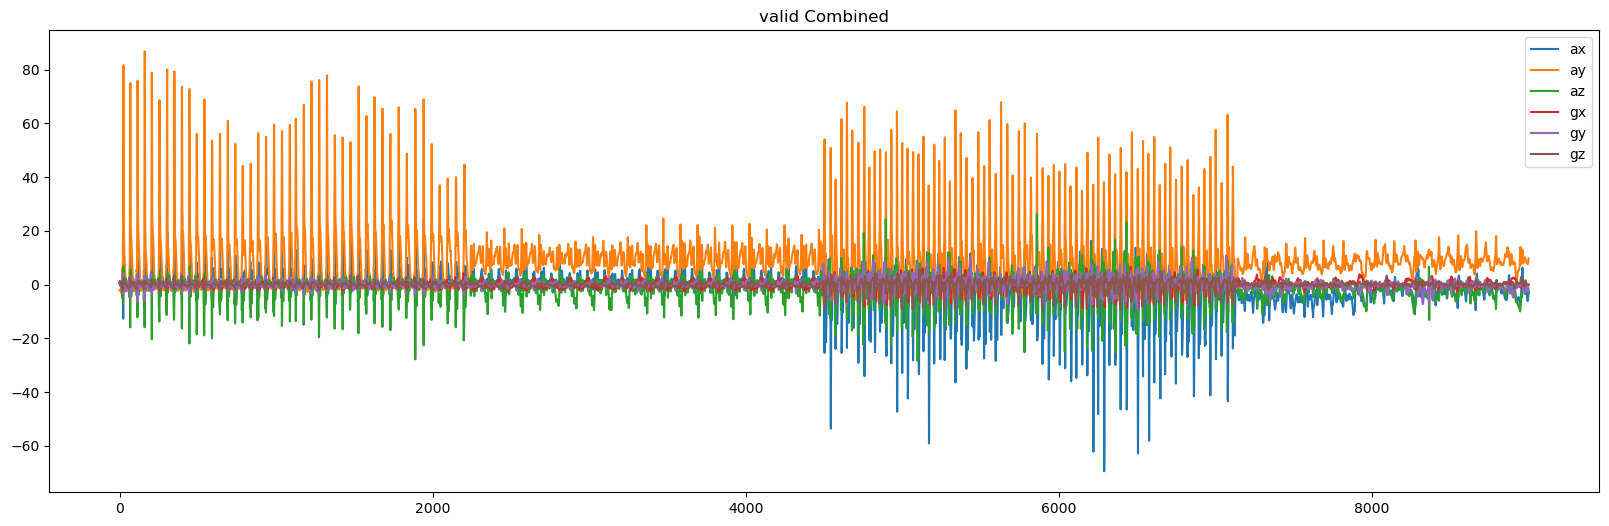

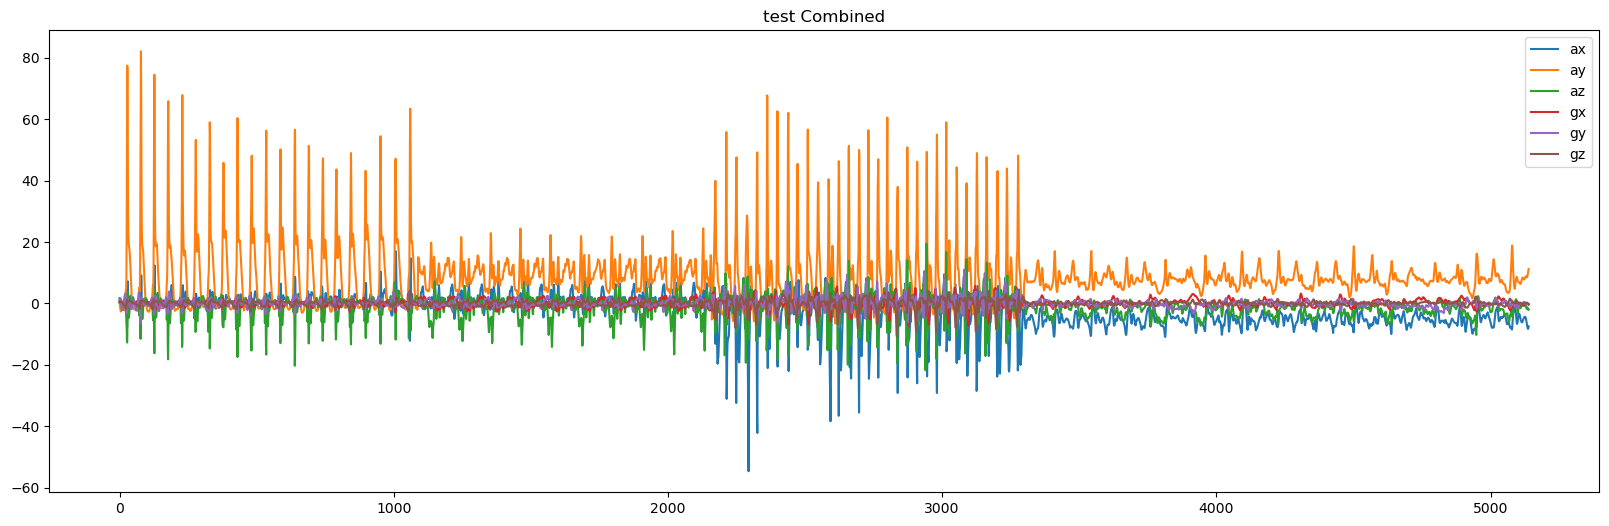

In [16]:
for category in categories:
    df = pd.read_pickle(f'../pickles/combined/{category}_df.pkl')
    df.plot(title=f"{category} Combined", figsize=(20, 6))
    plt.show()

## KNN vs Decision Tree

The KNN model achieved a higher test accuracy (91.7%) compared to the Decision Tree (87.5%), a difference of about 4 percentage points. The confusion matrices confirm this: both models show strong diagonals, but KNN has fewer off-diagonal errors. In particular, KNN classifies ‘stairs’ and ‘walking’ with very high accuracy, whereas the Decision Tree confuses ‘walking’ with both ‘jumping’ and ‘stairs’, and also confuses ‘stairs’ with ‘running’. Both models struggle somewhat with distinguishing ‘jumping’ from ‘running’, reflecting similarities in sensor patterns, but KNN handles these overlaps better overall. Thus, KNN provides better generalization performance on this dataset.